<h2>LEVEL 3 - TASK 2: NLP SENTIMENT ANALYSIS</h2>

<h3>Importing Dataset</h3>

In [5]:
import pandas as pd

# Loading our sentiment dataset
df = pd.read_csv("3) Sentiment dataset.csv")

# First 10 rows of the dataset
df.head(10)

,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,2,2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,3,3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,4,4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19
5,5,5,Feeling grateful for the little things in lif...,Positive,2023-01-16 09:10:00,GratitudeNow,Twitter,#Gratitude #PositiveVibes,25.0,50.0,India,2023,1,16,9
6,6,6,Rainy days call for cozy blankets and hot coc...,Positive,2023-01-16 14:45:00,RainyDays,Facebook,#RainyDays #Cozy,10.0,20.0,Canada,2023,1,16,14
7,7,7,The new movie release is a must-watch! ...,Positive,2023-01-16 19:30:00,MovieBuff,Instagram,#MovieNight #MustWatch,15.0,30.0,USA,2023,1,16,19
8,8,8,Political discussions heating up on the timel...,Negative,2023-01-17 08:00:00,DebateTalk,Twitter,#Politics #Debate,30.0,60.0,USA,2023,1,17,8
9,9,9,Missing summer vibes and beach days. ...,Neutral,2023-01-17 12:20:00,BeachLover,Facebook,#Summer #BeachDays,18.0,35.0,Australia,2023,1,17,12


In [6]:
# Drop the unnecessary column
df = df.drop(columns=['Unnamed: 0'], errors='ignore')
df = df.drop(columns=['Unnamed: 0.1'], errors='ignore')

# Rename column (replace '0' with the actual column name if different)
#df = df.rename(columns={'': 'ID'})

print(df.columns)
df.head()

Index(['Text', 'Sentiment', 'Timestamp', 'User', 'Platform', 'Hashtags',
       'Retweets', 'Likes', 'Country', 'Year', 'Month', 'Day', 'Hour'],
      dtype='object')


,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19


In [7]:
# Removing Extra Spaces
df['Sentiment'] = df['Sentiment'].str.strip()
df['Platform'] = df['Platform'].str.strip()
df['Country'] = df['Country'].str.strip()

# Convert to consistent capitalization
df['Sentiment'] = df['Sentiment'].str.title()
df['Platform'] = df['Platform'].str.title()
df['Country'] = df['Country'].str.upper()

# Check unique values after standardization
print("Unique Sentiments:", df['Sentiment'].unique())
print("Unique Platforms:", df['Platform'].unique())
print("Unique Countries:", df['Country'].unique())

Unique Sentiments: ['Positive' 'Negative' 'Neutral' 'Anger' 'Fear' 'Sadness' 'Disgust'
 'Happiness' 'Joy' 'Love' 'Amusement' 'Enjoyment' 'Admiration' 'Affection'
 'Awe' 'Disappointed' 'Surprise' 'Acceptance' 'Adoration' 'Anticipation'
 'Bitter' 'Calmness' 'Confusion' 'Excitement' 'Kind' 'Pride' 'Shame'
 'Elation' 'Euphoria' 'Contentment' 'Serenity' 'Gratitude' 'Hope'
 'Empowerment' 'Compassion' 'Tenderness' 'Arousal' 'Enthusiasm'
 'Fulfillment' 'Reverence' 'Despair' 'Grief' 'Loneliness' 'Jealousy'
 'Resentment' 'Frustration' 'Boredom' 'Anxiety' 'Intimidation'
 'Helplessness' 'Envy' 'Regret' 'Curiosity' 'Indifference' 'Numbness'
 'Melancholy' 'Nostalgia' 'Ambivalence' 'Determination' 'Zest' 'Hopeful'
 'Proud' 'Grateful' 'Empathetic' 'Compassionate' 'Playful' 'Free-Spirited'
 'Inspired' 'Confident' 'Bitterness' 'Yearning' 'Fearful' 'Apprehensive'
 'Overwhelmed' 'Jealous' 'Devastated' 'Frustrated' 'Envious' 'Dismissive'
 'Thrill' 'Bittersweet' 'Overjoyed' 'Inspiration' 'Motivation'
 'Cont

In [8]:
import re

def clean_text(text):
    text = text.strip()                          # Remove leading/trailing spaces
    text = text.lower()                          # Lowercase
    text = re.sub(r"http\S+|www\S+", "", text)  # Remove URLs
    text = re.sub(r"@\w+", "", text)            # Remove mentions
    text = re.sub(r"#\w+", "", text)            # Remove hashtags (optional)
    text = re.sub(r"[^a-zA-Z\s]", "", text)     # Remove punctuation & emojis
    text = re.sub(r"\s+", " ", text)            # Remove extra spaces
    return text

# Apply to the Text column
df['Clean_Text'] = df['Text'].apply(clean_text)

# Check the results
df[['Text', 'Clean_Text']].head()

,Text,Clean_Text
0,Enjoying a beautiful day at the park! ...,enjoying a beautiful day at the park
1,Traffic was terrible this morning. ...,traffic was terrible this morning
2,Just finished an amazing workout! 💪 ...,just finished an amazing workout
3,Excited about the upcoming weekend getaway! ...,excited about the upcoming weekend getaway
4,Trying out a new recipe for dinner tonight. ...,trying out a new recipe for dinner tonight


In [9]:
# Converting Timestamp column to datetime
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# Check results
print(df['Timestamp'].head())
print(df.dtypes)

0   2023-01-15 12:30:00
1   2023-01-15 08:45:00
2   2023-01-15 15:45:00
3   2023-01-15 18:20:00
4   2023-01-15 19:55:00
Name: Timestamp, dtype: datetime64[ns]
Text                  object
Sentiment             object
Timestamp     datetime64[ns]
User                  object
Platform              object
Hashtags              object
Retweets             float64
Likes                float64
Country               object
Year                   int64
Month                  int64
Day                    int64
Hour                   int64
Clean_Text            object
dtype: object


<h3>Processing Hashtags</h3>

In [10]:
# Convert empty strings to NaN for consistency
df['Hashtags'] = df['Hashtags'].replace('', pd.NA)

# Function to split hashtags into a list
def split_hashtags(text):
    if pd.isna(text):
        return []
    else:
        # Split by space and remove empty strings
        return [tag.strip() for tag in text.split() if tag.strip() != ""]

# Apply to Hashtags column
df['Hashtag_List'] = df['Hashtags'].apply(split_hashtags)

# Check results
df[['Hashtags', 'Hashtag_List']].head()

,Hashtags,Hashtag_List
0,#Nature #Park,"[#Nature, #Park]"
1,#Traffic #Morning,"[#Traffic, #Morning]"
2,#Fitness #Workout,"[#Fitness, #Workout]"
3,#Travel #Adventure,"[#Travel, #Adventure]"
4,#Cooking #Food,"[#Cooking, #Food]"


In [11]:
# Count number of hashtags in each post
df['Hashtag_Count'] = df['Hashtag_List'].apply(len)

# Check results
df[['Hashtag_List', 'Hashtag_Count']].head()

,Hashtag_List,Hashtag_Count
0,"[#Nature, #Park]",2
1,"[#Traffic, #Morning]",2
2,"[#Fitness, #Workout]",2
3,"[#Travel, #Adventure]",2
4,"[#Cooking, #Food]",2


<h2>LEVEL 3 - TASK 2: NLP SENTIMENT ANALYSIS</h2>

<h2>Importing NLTK</h2>

In [18]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\DUTCH\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\DUTCH\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


True

<h2>Preprocess text data - Tokenization</h2>

In [19]:
from nltk.tokenize import word_tokenize

text = "Enjoying a beautiful day at the park!"
tokens = word_tokenize(text)

print(tokens)

['Enjoying', 'a', 'beautiful', 'day', 'at', 'the', 'park', '!']


In [21]:
df['Tokens'] = df['Clean_Text'].apply(word_tokenize)

df[['Clean_Text', 'Tokens']].head()

,Clean_Text,Tokens
0,enjoying a beautiful day at the park,"[enjoying, a, beautiful, day, at, the, park]"
1,traffic was terrible this morning,"[traffic, was, terrible, this, morning]"
2,just finished an amazing workout,"[just, finished, an, amazing, workout]"
3,excited about the upcoming weekend getaway,"[excited, about, the, upcoming, weekend, getaway]"
4,trying out a new recipe for dinner tonight,"[trying, out, a, new, recipe, for, dinner, ton..."


<h2>Stopword Removal</h2>

In [22]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\DUTCH\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [23]:
from nltk.corpus import stopwords

# Load English stopwords
stop_words = set(stopwords.words('english'))

# Example
tokens = ['i', 'am', 'enjoying', 'a', 'beautiful', 'day', 'at', 'the', 'park']

filtered_tokens = [word for word in tokens if word not in stop_words]

print(filtered_tokens)

['enjoying', 'beautiful', 'day', 'park']


In [24]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

# Remove stopwords from your Tokens column
df['Filtered_Tokens'] = df['Tokens'].apply(
    lambda tokens: [word for word in tokens if word not in stop_words]
)

# Check results
df[['Tokens', 'Filtered_Tokens']].head()

,Tokens,Filtered_Tokens
0,"[enjoying, a, beautiful, day, at, the, park]","[enjoying, beautiful, day, park]"
1,"[traffic, was, terrible, this, morning]","[traffic, terrible, morning]"
2,"[just, finished, an, amazing, workout]","[finished, amazing, workout]"
3,"[excited, about, the, upcoming, weekend, getaway]","[excited, upcoming, weekend, getaway]"
4,"[trying, out, a, new, recipe, for, dinner, ton...","[trying, new, recipe, dinner, tonight]"


<h2>Stemming & Lemmatization</h2>

In [25]:
from nltk.stem import PorterStemmer

stemmer = PorterStemmer()

words = ['running', 'happiness', 'studies']

stemmed = [stemmer.stem(word) for word in words]
print(stemmed)

['run', 'happi', 'studi']


In [26]:
import nltk
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\DUTCH\AppData\Roaming\nltk_data...
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\DUTCH\AppData\Roaming\nltk_data...


True

In [27]:
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

words = ['running', 'better', 'studies']

lemmatized = [lemmatizer.lemmatize(word) for word in words]
print(lemmatized)

['running', 'better', 'study']


In [28]:
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

df['Lemmatized_Tokens'] = df['Filtered_Tokens'].apply(
    lambda tokens: [lemmatizer.lemmatize(word) for word in tokens]
)

df[['Filtered_Tokens', 'Lemmatized_Tokens']].head()

,Filtered_Tokens,Lemmatized_Tokens
0,"[enjoying, beautiful, day, park]","[enjoying, beautiful, day, park]"
1,"[traffic, terrible, morning]","[traffic, terrible, morning]"
2,"[finished, amazing, workout]","[finished, amazing, workout]"
3,"[excited, upcoming, weekend, getaway]","[excited, upcoming, weekend, getaway]"
4,"[trying, new, recipe, dinner, tonight]","[trying, new, recipe, dinner, tonight]"


<h2>Sentiment Analysis using TextBlob</h2>

In [29]:
from textblob import TextBlob

In [30]:
text = "I am enjoying a beautiful day at the park!"

blob = TextBlob(text)

# Polarity ranges from -1 (negative) to 1 (positive)
print("Polarity:", blob.sentiment.polarity)

# Subjectivity ranges from 0 (objective) to 1 (subjective)
print("Subjectivity:", blob.sentiment.subjectivity)

Polarity: 0.75
Subjectivity: 0.8


<h2>Classifying text as positive, negative, or neutral.</h2>

In [31]:
# Function to categorize sentiment
def get_sentiment(polarity):
    if polarity > 0:
        return 'Positive'
    elif polarity < 0:
        return 'Negative'
    else:
        return 'Neutral'

# Compute polarity
df['Polarity'] = df['Clean_Text'].apply(lambda x: TextBlob(x).sentiment.polarity)

# Assign sentiment label
df['Predicted_Sentiment'] = df['Polarity'].apply(get_sentiment)

# Preview
df[['Clean_Text', 'Polarity', 'Predicted_Sentiment']].head()

,Clean_Text,Polarity,Predicted_Sentiment
0,enjoying a beautiful day at the park,0.675000,Positive
1,traffic was terrible this morning,-1.000000,Negative
2,just finished an amazing workout,0.600000,Positive
3,excited about the upcoming weekend getaway,0.375000,Positive
4,trying out a new recipe for dinner tonight,0.136364,Positive


<h2>Visualizing Sentiment Distribution</h2>

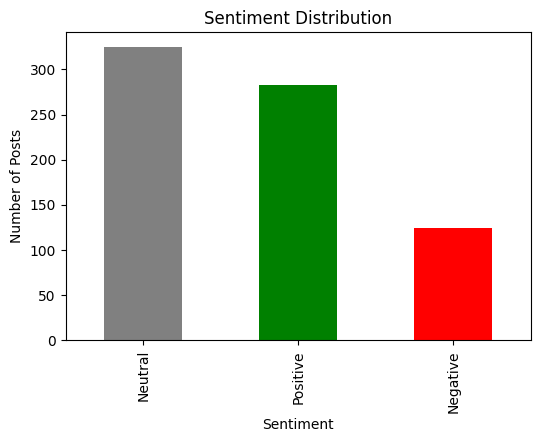

In [33]:
import matplotlib.pyplot as plt

# Count of each sentiment
sentiment_counts = df['Predicted_Sentiment'].value_counts()

# Plot
plt.figure(figsize=(6,4))
sentiment_counts.plot(kind='bar', color=['gray', 'green', 'red'])
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Number of Posts')
plt.show()

<h2>Word Cloud</h2>

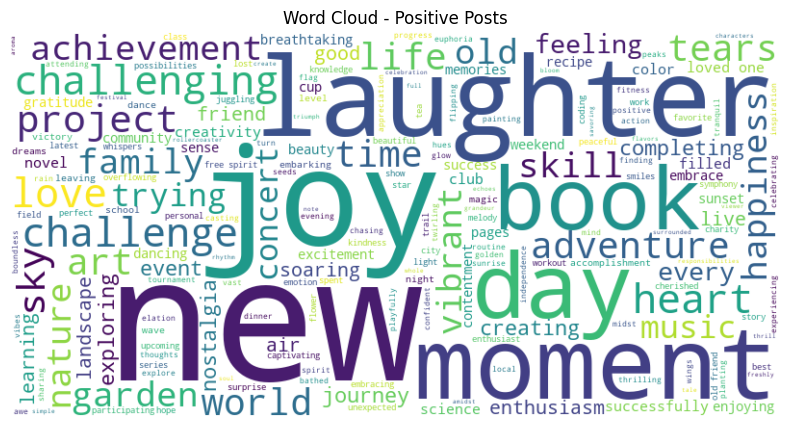

In [35]:
from wordcloud import WordCloud

# Combine all positive texts
positive_text = " ".join(df[df['Predicted_Sentiment']=='Positive']['Clean_Text'])

# Generate word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(positive_text)

# Display
plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud - Positive Posts')
plt.show()